<a href="https://colab.research.google.com/github/hieuvu-0111/Lotka-Volterra-Model-Visualization/blob/main/Lotka_Volterra_Model_Visualization_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

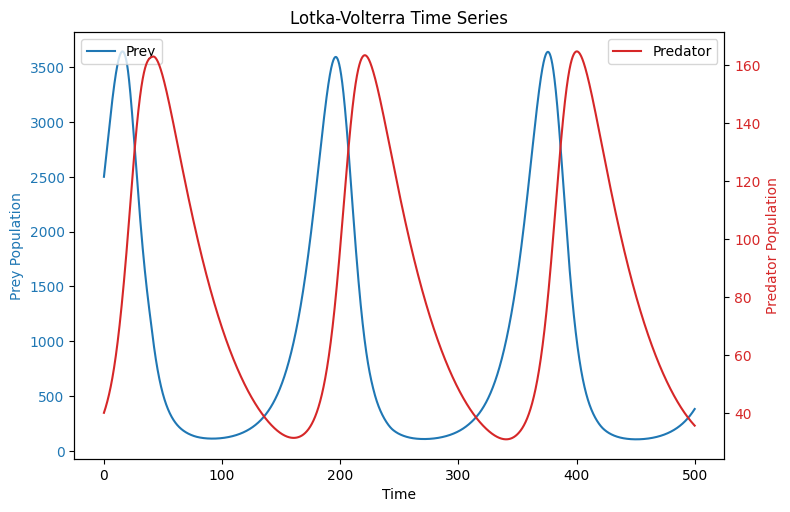

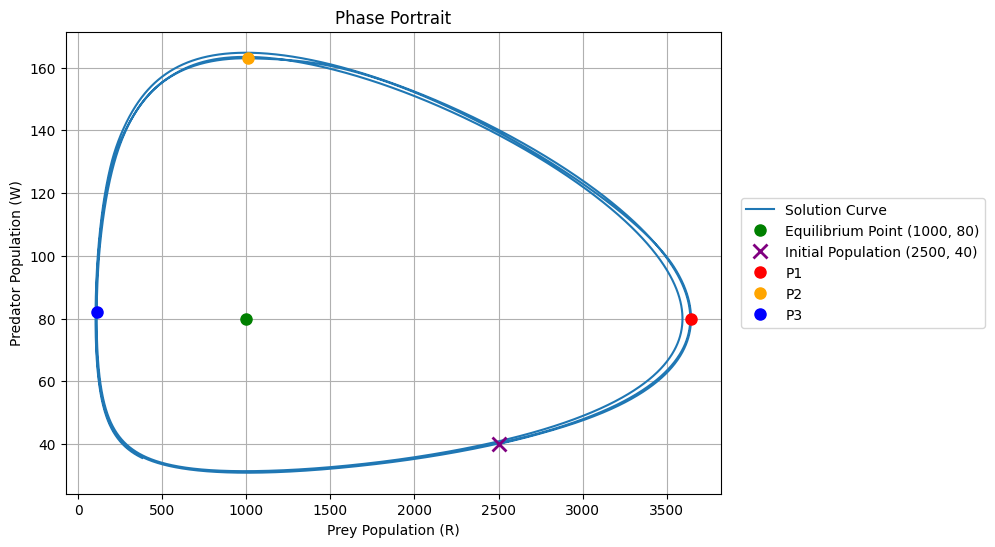

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Lotka–Volterra system
def lotka_volterra(t, z, a, b, c, d):
    x, y = z
    dxdt = a*x - b*x*y
    dydt = -c*y + d*x*y
    return [dxdt, dydt]

# Parameters
a = 0.08       # prey growth rate
b = 0.001       # predation rate
c = 0.02       # predator death rate
d = 0.00002     # predator growth per prey eaten

# Initial conditions
z0 = [2500, 40]  # initial prey and predator populations

# Time span
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

# Solve ODE
sol = solve_ivp(lotka_volterra, t_span, z0, t_eval=t_eval, args=(a, b, c, d))

x = sol.y[0]
y = sol.y[1]
t = sol.t

# GRAPH 1: Time series with two y-axes
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Prey Population', color=color)
ax1.plot(t, x, color=color, label='Prey')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Predator Population', color=color)
ax2.plot(t, y, color=color, label='Predator')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

fig.tight_layout()
plt.title('Lotka-Volterra Time Series')
plt.show()


# GRAPH 2: Phase portrait
fig2, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, label='Solution Curve')

# Plot the equilibrium point
ax.plot(1000, 80, 'o', color='green', markersize=8, label='Equilibrium Point (1000, 80)')

# Plot the initial population point
ax.plot(z0[0], z0[1], 'x', color='purple', markersize=10, markeredgewidth=2,
        label=f'Initial Population ({z0[0]}, {z0[1]})')

# Identify and plot P1, P2, P3 from the solution curve
# P1: very right point of the phase portrait (where R max)
idx_P1 = np.argmax(x)
P1_x = x[idx_P1]
P1_y = y[idx_P1]
ax.plot(P1_x, P1_y, 'o', color='red', markersize=8, label='P1')

# P2: lies on the phase and R=1000 (after R max, before R min)
indices_after_P1 = np.arange(idx_P1, len(x))
idx_P2_candidates = np.where(x[indices_after_P1] <= 1000 + 10)[0]
if len(idx_P2_candidates) > 0:
    idx_P2 = indices_after_P1[idx_P2_candidates[0]]
else:
    idx_P2 = np.argmin(np.abs(x - 1000))

P2_x = x[idx_P2]
P2_y = y[idx_P2]
ax.plot(P2_x, P2_y, 'o', color='orange', markersize=8, label='P2')

# P3: when W=80 and lies on the curve (after P2, before W min)
indices_after_P2 = np.arange(idx_P2, len(y))
idx_P3_candidates = np.where(y[indices_after_P2] <= 80 + 2)[0]
if len(idx_P3_candidates) > 0:
    idx_P3 = indices_after_P2[idx_P3_candidates[0]]
else:
    idx_P3 = np.argmin(np.abs(y - 80))

P3_x = x[idx_P3]
P3_y = y[idx_P3]
ax.plot(P3_x, P3_y, 'o', color='blue', markersize=8, label='P3')

# Labels and title
ax.set_xlabel("Prey Population (R)")
ax.set_ylabel("Predator Population (W)")
ax.set_title("Phase Portrait")

ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)

# Add grid to the phase portrait
ax.grid(True)

plt.subplots_adjust(right=0.78)

plt.show()
